In [1]:
import json
import requests
import pandas as pd
import numpy as np


# =========================
# SkillCorner Remote Sources
# =========================

MATCH_ID = 1886347
MAX_FRAMES = None  

SC_BASE_URL = "https://raw.githubusercontent.com/SkillCorner/opendata/master/data/matches"
SC_LFS_URL = "https://media.githubusercontent.com/media/SkillCorner/opendata/master/data/matches"

SC_META_SOURCE = f"{SC_BASE_URL}/{MATCH_ID}/{MATCH_ID}_match.json"
SC_DYNAMIC_EVENTS_SOURCE = f"{SC_BASE_URL}/{MATCH_ID}/{MATCH_ID}_dynamic_events.csv"
SC_PHASES_SOURCE = f"{SC_BASE_URL}/{MATCH_ID}/{MATCH_ID}_phases_of_play.csv"
SC_TRACKING_SOURCE = f"{SC_LFS_URL}/{MATCH_ID}/{MATCH_ID}_tracking_extrapolated.jsonl"

print("SkillCorner remote sources ready.")
print(SC_META_SOURCE)
print(SC_TRACKING_SOURCE)

SkillCorner remote sources ready.
https://raw.githubusercontent.com/SkillCorner/opendata/master/data/matches/1886347/1886347_match.json
https://media.githubusercontent.com/media/SkillCorner/opendata/master/data/matches/1886347/1886347_tracking_extrapolated.jsonl


In [2]:
def load_json_url(url: str) -> dict:
    """
    Load JSON from a remote URL.
    """
    response = requests.get(url, timeout=60)
    response.raise_for_status()
    return response.json()


def iter_jsonl_url(url: str):
    """
    Stream a remote JSONL file line by line.

    Important:
    tracking_extrapolated.jsonl can be large, so we stream it instead of
    downloading the full file into memory first.
    """
    with requests.get(url, stream=True, timeout=120) as response:
        response.raise_for_status()

        for line in response.iter_lines(decode_unicode=True):
            if line:
                yield line

In [3]:
meta = load_json_url(SC_META_SOURCE)

pitch_len = meta["pitch_length"]
pitch_wid = meta["pitch_width"]

periods = {p["period"]: p for p in meta["match_periods"]}

home_team = meta["home_team"]["short_name"]
away_team = meta["away_team"]["short_name"]

print(f"{home_team} vs {away_team} | pitch {pitch_len}x{pitch_wid}m")
print(f"Periods: {list(periods.keys())}")
print(f"{len(meta['players'])} players in lineup.")

Auckland FC vs Newcastle | pitch 104x68m
Periods: [1, 2]
36 players in lineup.


In [4]:
id_to_name = {}
id_to_team = {}

team_name = {
    meta["home_team"]["id"]: meta["home_team"]["short_name"],
    meta["away_team"]["id"]: meta["away_team"]["short_name"],
}


def register_player_key(key, player_name, player_team):
    """
    Register multiple possible player identifier formats.

    SkillCorner tracking may reference a player by:
    - trackable_object
    - id
    - player_id

    We store both original and string versions to avoid dtype mismatch.
    """
    if key is None:
        return

    id_to_name[key] = player_name
    id_to_team[key] = player_team

    id_to_name[str(key)] = player_name
    id_to_team[str(key)] = player_team


for player in meta["players"]:
    player_name = (
        player.get("short_name")
        or f"{player.get('first_name', '')} {player.get('last_name', '')}".strip()
        or "Unknown Player"
    )

    player_team = team_name.get(player.get("team_id"), "Unknown Team")

    possible_keys = [
        player.get("trackable_object"),
        player.get("id"),
        player.get("player_id"),
    ]

    for key in possible_keys:
        register_player_key(key, player_name, player_team)

print(f"{len(meta['players'])} players in lineup.")
print(f"{len(id_to_name)} player identifier keys registered.")

36 players in lineup.
144 player identifier keys registered.


In [5]:
dynamic_events = pd.read_csv(SC_DYNAMIC_EVENTS_SOURCE)
phases = pd.read_csv(SC_PHASES_SOURCE)

print("Dynamic events:", dynamic_events.shape)
print("Phases of play:", phases.shape)

display(dynamic_events.head())
display(phases.head())



Dynamic events: (5079, 294)
Phases of play: (454, 44)


,event_id,index,match_id,frame_start,frame_end,frame_physical_start,time_start,time_end,minute_start,second_start,...,xloss_player_possession_end,xloss_player_possession_max,xshot_player_possession_start,xshot_player_possession_end,xshot_player_possession_max,is_player_possession_start_matched,is_player_possession_end_matched,is_previous_pass_matched,is_pass_reception_matched,fully_extrapolated
0,8_0,0,1886347,28,28,NaN,00:01.8,00:01.8,0,1,...,NaN,NaN,NaN,NaN,NaN,True,True,NaN,True,False
1,8_1,1,1886347,48,58,NaN,00:03.8,00:04.8,0,3,...,NaN,NaN,NaN,NaN,NaN,True,True,True,True,False
2,7_0,2,1886347,48,53,NaN,00:03.8,00:04.3,0,3,...,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,False
3,7_1,3,1886347,48,58,NaN,00:03.8,00:04.8,0,3,...,NaN,NaN,NaN,NaN,NaN,True,True,NaN,True,False
4,9_0,4,1886347,56,58,34.0,00:02.4,00:04.8,0,2,...,NaN,NaN,NaN,NaN,NaN,True,True,True,True,NaN


,index,match_id,frame_start,frame_end,time_start,time_end,minute_start,second_start,duration,period,...,third_end,penalty_area_end,team_in_possession_width_start,team_in_possession_width_end,team_in_possession_length_start,team_in_possession_length_end,team_out_of_possession_width_start,team_out_of_possession_width_end,team_out_of_possession_length_start,team_out_of_possession_length_end
0,0,1886347,28,89,00:01.8,00:07.9,0,1,6.1,1,...,middle_third,False,51.72,54.41,41.44,58.03,34.37,32.81,42.01,52.35
1,1,1886347,89,107,00:07.9,00:09.7,0,7,1.8,1,...,attacking_third,False,54.72,54.54,58.24,62.34,32.97,34.26,51.98,46.99
2,2,1886347,185,232,00:17.5,00:22.2,0,17,4.7,1,...,defensive_third,False,45.30,50.78,48.51,50.31,31.40,36.38,54.72,51.13
3,3,1886347,232,283,00:22.2,00:27.3,0,22,5.1,1,...,attacking_third,False,50.81,42.83,50.33,63.89,36.59,38.73,51.22,53.46
4,4,1886347,283,301,00:27.3,00:29.1,0,27,1.8,1,...,defensive_third,False,38.61,36.66,53.59,54.36,42.62,40.13,64.54,71.83


In [6]:
from typing import Any, Dict, Iterable, Optional


FPS = int(meta.get("fps", meta.get("frame_rate", 10))) if isinstance(meta, dict) else 10


def first_present(d: Dict[str, Any], keys: Iterable[str], default: Any = None) -> Any:
    """
    Return the first non-null value among possible keys.
    """
    for key in keys:
        if key in d and d[key] is not None:
            return d[key]
    return default


def coerce_bool(value: Any) -> Any:
    """
    Convert common boolean-like values to True/False.
    Unknown values are kept as pd.NA.
    """
    if value is None:
        return pd.NA

    if isinstance(value, bool):
        return value

    if isinstance(value, (int, float)) and not pd.isna(value):
        return bool(value)

    if isinstance(value, str):
        value_clean = value.strip().lower()

        if value_clean in {"true", "1", "yes", "y"}:
            return True

        if value_clean in {"false", "0", "no", "n"}:
            return False

    return pd.NA


def normalize_identifier(value: Any) -> Optional[str]:
    """
    Normalize player IDs so integer/string mismatches do not break mapping.
    """
    if value is None or pd.isna(value):
        return None

    if isinstance(value, float) and value.is_integer():
        return str(int(value))

    return str(value)


def build_string_map(mapping: Dict[Any, Any]) -> Dict[str, Any]:
    """
    Convert mixed-type ID mapping into string-normalized mapping.
    """
    clean_mapping = {}

    for key, value in mapping.items():
        norm_key = normalize_identifier(key)
        if norm_key is not None:
            clean_mapping[norm_key] = value

    return clean_mapping


def load_skillcorner_tracking_long_remote(
    tracking_url: str,
    id_to_name: Dict[Any, str],
    id_to_team: Dict[Any, str],
    fps: int = 10,
    max_frames: Optional[int] = None,
) -> pd.DataFrame:
    """
    Parse remote SkillCorner tracking JSONL into one row per player per frame.

    Football analytics note:
    `is_detected` is critical. A detected position is a real camera observation;
    an extrapolated position is model-filled. We should keep both, but never
    forget which is which.
    """
    rows = []
    parsed_frames = 0

    for line_no, line in enumerate(iter_jsonl_url(tracking_url), start=1):
        if max_frames is not None and parsed_frames >= max_frames:
            break

        frame_record = json.loads(line)

        frame = first_present(
            frame_record,
            keys=["frame", "frame_id", "frame_number"],
        )

        period = first_present(
            frame_record,
            keys=["period", "period_id", "match_period"],
        )

        player_data = frame_record.get("player_data", [])

        for player in player_data:
            player_id = first_present(
                player,
                keys=["player_id", "id", "trackable_object"],
            )

            x = first_present(
                player,
                keys=["x", "x_position", "x_coord"],
            )

            y = first_present(
                player,
                keys=["y", "y_position", "y_coord"],
            )

            is_detected = coerce_bool(
                first_present(
                    player,
                    keys=["is_detected", "detected"],
                )
            )

            rows.append(
                {
                    "frame": frame,
                    "period": period,
                    "player_id": player_id,
                    "x": x,
                    "y": y,
                    "is_detected": is_detected,
                }
            )

        parsed_frames += 1

    trk = pd.DataFrame(rows)

    if trk.empty:
        raise ValueError("Tracking dataframe is empty. Check URL or JSONL schema.")

    required_cols = ["frame", "period", "player_id", "x", "y", "is_detected"]
    missing_cols = [col for col in required_cols if col not in trk.columns]

    if missing_cols:
        raise ValueError(f"Missing required columns after parsing: {missing_cols}")

    trk["frame"] = pd.to_numeric(trk["frame"], errors="coerce")
    trk["period"] = pd.to_numeric(trk["period"], errors="coerce")
    trk["x"] = pd.to_numeric(trk["x"], errors="coerce")
    trk["y"] = pd.to_numeric(trk["y"], errors="coerce")

    trk["minute"] = trk["frame"] / fps / 60
    trk["player_id_key"] = trk["player_id"].map(normalize_identifier)

    id_to_name_str = build_string_map(id_to_name)
    id_to_team_str = build_string_map(id_to_team)

    trk["name"] = trk["player_id_key"].map(id_to_name_str).fillna("unmapped")
    trk["team"] = trk["player_id_key"].map(id_to_team_str).fillna("?")

    return trk

In [7]:
trk = load_skillcorner_tracking_long_remote(
    tracking_url=SC_TRACKING_SOURCE,
    id_to_name=id_to_name,
    id_to_team=id_to_team,
    fps=FPS,
    max_frames=MAX_FRAMES,
)

detected_known = trk["is_detected"].dropna()
extrapolated_rate = detected_known.eq(False).mean()

print(
    f"{len(trk):,} player-frames | "
    f"{trk['player_id_key'].nunique():,} tracked ids | "
    f"{extrapolated_rate:.0%} of positions are EXTRAPOLATED, not seen"
)

trk.head(25)

956,076 player-frames | 29 tracked ids | 41% of positions are EXTRAPOLATED, not seen


,frame,period,player_id,x,y,is_detected,minute,player_id_key,name,team
0,10,1,51009,-39.63,-0.08,False,0.016667,51009,R. Scott,Newcastle
1,10,1,176224,-19.21,-9.18,True,0.016667,176224,P. Cancar,Newcastle
2,10,1,51649,-21.83,0.47,True,0.016667,51649,A. Šušnjar,Newcastle
3,10,1,50983,-1.16,-32.47,True,0.016667,50983,D. Ingham,Newcastle
4,10,1,735578,-18.88,15.73,True,0.016667,735578,M. Natta,Newcastle
5,10,1,50978,-7.41,7.13,True,0.016667,50978,C. Timmins,Newcastle
6,10,1,735574,-9.51,-5.01,True,0.016667,735574,K. Grozos,Newcastle
7,10,1,795507,-2.50,7.27,False,0.016667,795507,L. Bayliss,Newcastle
8,10,1,795505,-0.78,-20.69,True,0.016667,795505,E. Adams,Newcastle
9,10,1,735573,-1.85,18.80,True,0.016667,735573,T. Aquilina,Newcastle


In [8]:
def tracking_quality_report(trk: pd.DataFrame) -> pd.DataFrame:
    """
    Compact quality report for SkillCorner tracking data.
    """
    detected_known = trk["is_detected"].dropna()

    report = {
        "player_frames": len(trk),
        "unique_frames": trk["frame"].nunique(),
        "unique_tracked_ids": trk["player_id_key"].nunique(),
        "detected_pct": detected_known.eq(True).mean(),
        "extrapolated_pct": detected_known.eq(False).mean(),
        "unknown_detected_flag_pct": trk["is_detected"].isna().mean(),
        "missing_x_pct": trk["x"].isna().mean(),
        "missing_y_pct": trk["y"].isna().mean(),
        "unmapped_player_pct": trk["name"].eq("unmapped").mean(),
        "x_min": trk["x"].min(),
        "x_max": trk["x"].max(),
        "y_min": trk["y"].min(),
        "y_max": trk["y"].max(),
    }

    return pd.DataFrame(report.items(), columns=["metric", "value"])


qa_report = tracking_quality_report(trk)
qa_report

,metric,value
0,player_frames,956076.000000
1,unique_frames,43458.000000
2,unique_tracked_ids,29.000000
3,detected_pct,0.592817
4,extrapolated_pct,0.407183
5,unknown_detected_flag_pct,0.000000
6,missing_x_pct,0.000000
7,missing_y_pct,0.000000
8,unmapped_player_pct,0.000000
9,x_min,-57.050000


In [9]:
# =========================
# Broadcast coverage over time
# =========================

cov = trk.groupby("frame")["is_detected"].mean().sort_index()
cov_min = cov.groupby(np.floor(cov.index / FPS / 60).astype(int)).mean()

fig, ax = plt.subplots(figsize=(11, 3.2))

ax.fill_between(cov_min.index, cov_min.values, color="#2a9d8f", alpha=0.35)
ax.plot(cov_min.index, cov_min.values, color="#2a9d8f", lw=2)

ax.axhline(
    cov.mean(),
    ls="--",
    color="#e76f51",
    label=f"match average = {cov.mean():.0%} detected"
)

ax.set(
    xlabel="minute",
    ylabel="share of players actually seen",
    ylim=(0, 1),
    title="Broadcast coverage over time — the rest is extrapolation"
)

ax.legend()
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

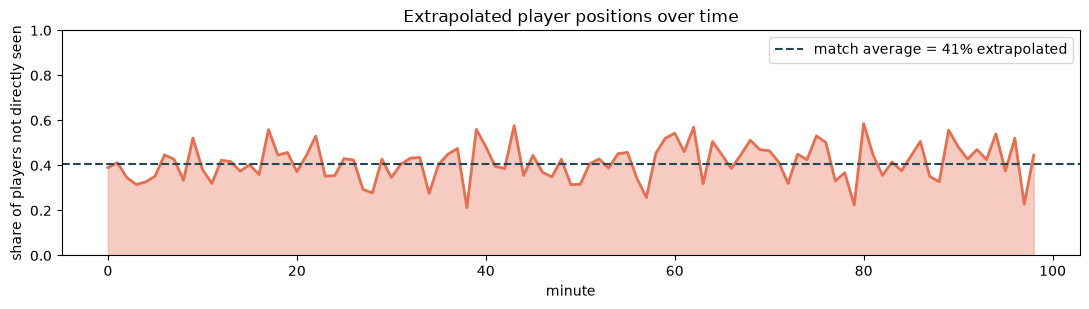

In [ ]:
# =========================
# Missing / extrapolated coverage over time
# =========================

miss = 1 - trk.groupby("frame")["is_detected"].mean().sort_index()
miss_min = miss.groupby((miss.index / FPS / 60).round().astype(int)).mean()

fig, ax = plt.subplots(figsize=(11, 3.2))

ax.fill_between(miss_min.index, miss_min.values, color="#e76f51", alpha=0.35)
ax.plot(miss_min.index, miss_min.values, color="#e76f51", lw=2)

ax.axhline(
    miss.mean(),
    ls="--",
    color="#264653",
    label=f"match average = {miss.mean():.0%} extrapolated"
)

ax.set(
    xlabel="minute",
    ylabel="share of players not directly seen",
    ylim=(0, 1),
    title="Extrapolated player positions over time"
)

ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# Player Visibility Report
# =========================

player_visibility = (
    trk
    .groupby(["team", "name", "player_id_key"], dropna=False)
    .agg(
        player_frames=("frame", "size"),
        unique_frames=("frame", "nunique"),
        detected_frames=("is_detected", lambda s: s.eq(True).sum()),
        extrapolated_frames=("is_detected", lambda s: s.eq(False).sum()),
        detected_pct=("is_detected", lambda s: s.eq(True).mean()),
        extrapolated_pct=("is_detected", lambda s: s.eq(False).mean()),
        first_minute=("minute", "min"),
        last_minute=("minute", "max"),
        mean_x=("x", "mean"),
        mean_y=("y", "mean"),
    )
    .reset_index()
)

player_visibility = player_visibility.sort_values(
    ["detected_pct", "player_frames"],
    ascending=[False, False]
)

player_visibility.head(15)

,team,name,player_id_key,player_frames,unique_frames,detected_frames,extrapolated_frames,detected_pct,extrapolated_pct,first_minute,last_minute,mean_x,mean_y
25,Newcastle,M. Scarcella,797297,4171,4171,3309,862,0.793335,0.206665,86.996667,98.396667,8.055382,-2.052649
17,Newcastle,C. Timmins,50978,39287,39287,29312,9975,0.746099,0.253901,0.016667,86.068333,0.920756,-3.560945
4,Auckland FC,F. Gallegos,23418,43458,43458,32231,11227,0.741659,0.258341,0.016667,98.396667,1.032326,-2.848402
11,Auckland FC,N. Moreno,43829,10190,10190,7518,2672,0.737782,0.262218,71.431667,98.396667,11.900561,-12.405094
22,Newcastle,K. Grozos,735574,43458,43458,31874,11584,0.733444,0.266556,0.016667,98.396667,0.335682,2.162260
9,Auckland FC,L. Verstraete,14736,43458,43458,31385,12073,0.722192,0.277808,0.016667,98.396667,1.614042,-1.216478
20,Newcastle,E. Adams,795505,39287,39287,28332,10955,0.721155,0.278845,0.016667,86.068333,0.434635,-7.888996
28,Newcastle,T. Aquilina,735573,43458,43458,31203,12255,0.718004,0.281996,0.016667,98.396667,0.092506,8.223913
8,Auckland FC,L. Rogerson,133501,33268,33268,23646,9622,0.710773,0.289227,0.016667,71.016667,-3.919438,5.067545
10,Auckland FC,M. Mata,163972,7612,7612,5252,2360,0.689963,0.310037,78.756667,98.396667,16.385849,-3.880466


In [ ]:
# =========================
# Pick the most visible player
# =========================

MIN_PLAYER_FRAMES = 3000

best_visible_players = (
    player_visibility[player_visibility["player_frames"] >= MIN_PLAYER_FRAMES]
    .sort_values(["detected_pct", "player_frames"], ascending=[False, False])
    .reset_index(drop=True)
)

best_visible_players.head(10)

,team,name,player_id_key,player_frames,unique_frames,detected_frames,extrapolated_frames,detected_pct,extrapolated_pct,first_minute,last_minute,mean_x,mean_y
0,Newcastle,M. Scarcella,797297,4171,4171,3309,862,0.793335,0.206665,86.996667,98.396667,8.055382,-2.052649
1,Newcastle,C. Timmins,50978,39287,39287,29312,9975,0.746099,0.253901,0.016667,86.068333,0.920756,-3.560945
2,Auckland FC,F. Gallegos,23418,43458,43458,32231,11227,0.741659,0.258341,0.016667,98.396667,1.032326,-2.848402
3,Auckland FC,N. Moreno,43829,10190,10190,7518,2672,0.737782,0.262218,71.431667,98.396667,11.900561,-12.405094
4,Newcastle,K. Grozos,735574,43458,43458,31874,11584,0.733444,0.266556,0.016667,98.396667,0.335682,2.162260
5,Auckland FC,L. Verstraete,14736,43458,43458,31385,12073,0.722192,0.277808,0.016667,98.396667,1.614042,-1.216478
6,Newcastle,E. Adams,795505,39287,39287,28332,10955,0.721155,0.278845,0.016667,86.068333,0.434635,-7.888996
7,Newcastle,T. Aquilina,735573,43458,43458,31203,12255,0.718004,0.281996,0.016667,98.396667,0.092506,8.223913
8,Auckland FC,L. Rogerson,133501,33268,33268,23646,9622,0.710773,0.289227,0.016667,71.016667,-3.919438,5.067545
9,Auckland FC,M. Mata,163972,7612,7612,5252,2360,0.689963,0.310037,78.756667,98.396667,16.385849,-3.880466


In [ ]:
target_player = best_visible_players.iloc[0]

TARGET_PLAYER_ID = target_player["player_id_key"]
TARGET_PLAYER_NAME = target_player["name"]
TARGET_PLAYER_TEAM = target_player["team"]

print(f"Selected player: {TARGET_PLAYER_NAME} ({TARGET_PLAYER_TEAM})")
print(f"Detected pct: {target_player['detected_pct']:.1%}")
print(f"Extrapolated pct: {target_player['extrapolated_pct']:.1%}")
print(f"Frames: {target_player['player_frames']:,}")

Selected player: M. Scarcella (Newcastle)
Detected pct: 79.3%
Extrapolated pct: 20.7%
Frames: 4,171


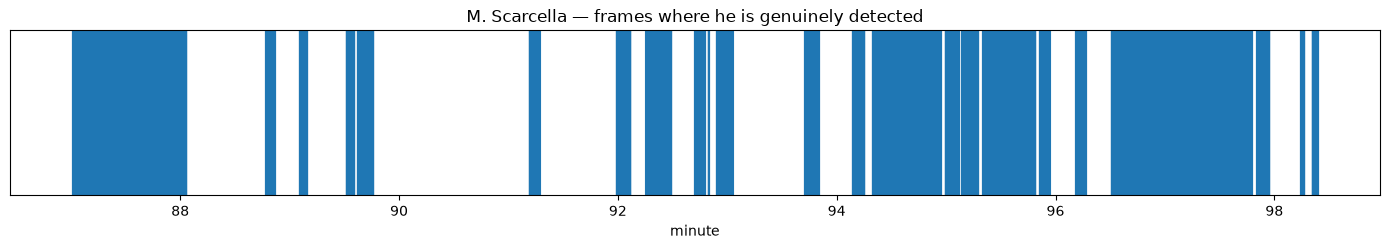

M. Scarcella is one of the most visible players in the match, yet 20.7% of his tracked positions are still extrapolated.


In [ ]:
# =========================
# Disappearing Player — genuinely detected frames
# =========================

player_track = (
    trk[trk["player_id_key"] == TARGET_PLAYER_ID]
    .sort_values("frame")
    .copy()
)

detected_only = player_track[player_track["is_detected"].eq(True)]

fig, ax = plt.subplots(figsize=(14, 2.6))

ax.vlines(
    detected_only["minute"],
    ymin=0,
    ymax=1,
    linewidth=0.8,
)

ax.set_title(f"{TARGET_PLAYER_NAME} — frames where he is genuinely detected")
ax.set_xlabel("minute")
ax.set_yticks([])
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(
    f"{TARGET_PLAYER_NAME} is one of the most visible players in the match, "
    f"yet {target_player['extrapolated_pct']:.1%} of his tracked positions are still extrapolated."
)

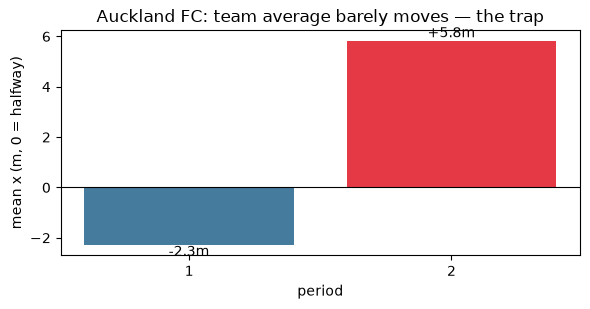

period
1   -2.297083
2    5.834047
Name: x, dtype: float64


In [ ]:
# =========================
# Half-time direction flip — quick team-average check
# =========================

home = home_team   # daha önce meta'dan çekmiştik: meta["home_team"]["short_name"]

h = trk[(trk["team"] == home) & (trk["is_detected"].eq(True))].copy()

flip = (
    h.groupby("period")["x"]
    .mean()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(6, 3.2))

colors = ["#457b9d" if v < 0 else "#e63946" for v in flip.values]

ax.bar(
    flip.index.astype(str),
    flip.values,
    color=colors
)

ax.axhline(0, color="k", lw=0.8)

ax.set(
    xlabel="period",
    ylabel="mean x (m, 0 = halfway)",
    title=f"{home}: team average barely moves — the trap"
)

for p, v in flip.items():
    ax.text(
        str(p),
        v,
        f"{v:+.1f}m",
        ha="center",
        va="bottom" if v >= 0 else "top"
    )

plt.tight_layout()
plt.show()

print(flip)

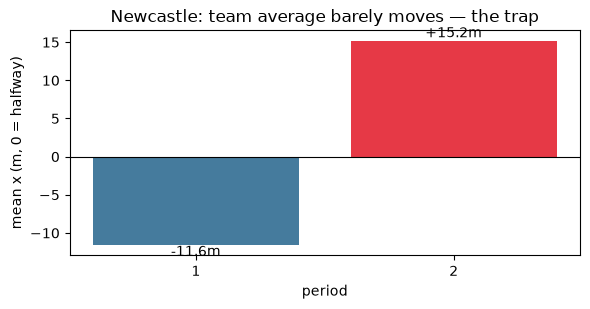

period
1   -11.615620
2    15.212336
Name: x, dtype: float64


In [ ]:
# =========================
# Away team quick check
# =========================

away = away_team

a = trk[(trk["team"] == away) & (trk["is_detected"].eq(True))].copy()

flip_away = (
    a.groupby("period")["x"]
    .mean()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(6, 3.2))

colors = ["#457b9d" if v < 0 else "#e63946" for v in flip_away.values]

ax.bar(
    flip_away.index.astype(str),
    flip_away.values,
    color=colors
)

ax.axhline(0, color="k", lw=0.8)

ax.set(
    xlabel="period",
    ylabel="mean x (m, 0 = halfway)",
    title=f"{away}: team average barely moves — the trap"
)

for p, v in flip_away.items():
    ax.text(
        str(p),
        v,
        f"{v:+.1f}m",
        ha="center",
        va="bottom" if v >= 0 else "top"
    )

plt.tight_layout()
plt.show()

print(flip_away)

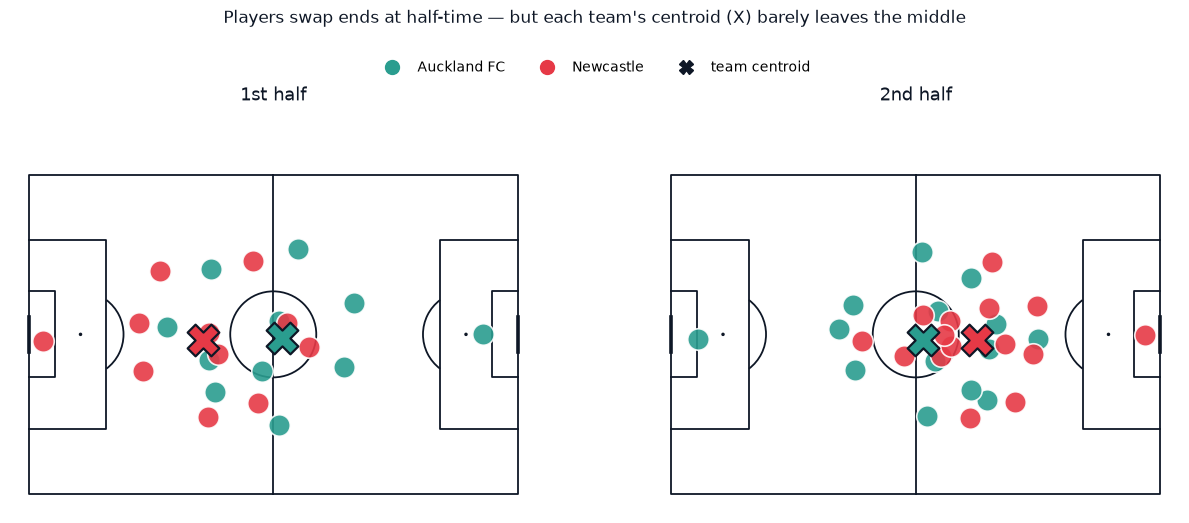

In [ ]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# =========================
# Mean player positions by team and half
# =========================

pos = (
    trk[trk["is_detected"].eq(True)]
    .groupby(["team", "period", "name"], as_index=False)[["x", "y"]]
    .mean()
)

PL = meta["pitch_length"]
PW = meta["pitch_width"]

home = home_team
away = away_team

colors = {
    home: "#2a9d8f",
    away: "#e63946",
}

pitch = Pitch(
    pitch_type="custom",
    pitch_length=PL,
    pitch_width=PW,
    line_color="#0E1726",
    linewidth=1.3,
    pad_top=14,
)

fig, axs = pitch.draw(nrows=1, ncols=2, figsize=(13, 4.8))

# axs bazen numpy array, bazen list benzeri gelir; düzleştirelim
axs = axs.flatten() if hasattr(axs, "flatten") else axs

for ax, period in zip(axs, [1, 2]):
    half = pos[pos["period"] == period].copy()

    for team, col in colors.items():
        t = half[half["team"] == team].copy()

        # SkillCorner koordinatları merkez-orijinli.
        # mplsoccer custom pitch corner-origin ile daha rahat çizilir.
        X = t["x"] + PL / 2
        Y = t["y"] + PW / 2

        # Oyuncu ortalama konumları
        pitch.scatter(
            X,
            Y,
            ax=ax,
            s=240,
            color=col,
            edgecolors="white",
            linewidth=1.2,
            alpha=0.9,
            zorder=3,
        )

        # Takım centroid'i
        pitch.scatter(
            X.mean(),
            Y.mean(),
            ax=ax,
            s=520,
            marker="X",
            color=col,
            edgecolors="#0E1726",
            linewidth=1.6,
            zorder=4,
        )

    ax.set_title(
        f"{'1st' if period == 1 else '2nd'} half",
        fontsize=13,
        color="#0E1726",
    )

handles = [
    mlines.Line2D([], [], marker="o", ls="", color=c, markersize=10, label=t)
    for t, c in colors.items()
]
handles.append(
    mlines.Line2D(
        [], [], marker="X", ls="", color="#0E1726", markersize=10, label="team centroid"
    )
)

fig.legend(
    handles=handles,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.0),
)

fig.suptitle(
    "Players swap ends at half-time — but each team's centroid (X) barely leaves the middle",
    y=1.08,
    fontsize=12.5,
    color="#0E1726",
)

plt.tight_layout()
plt.show()

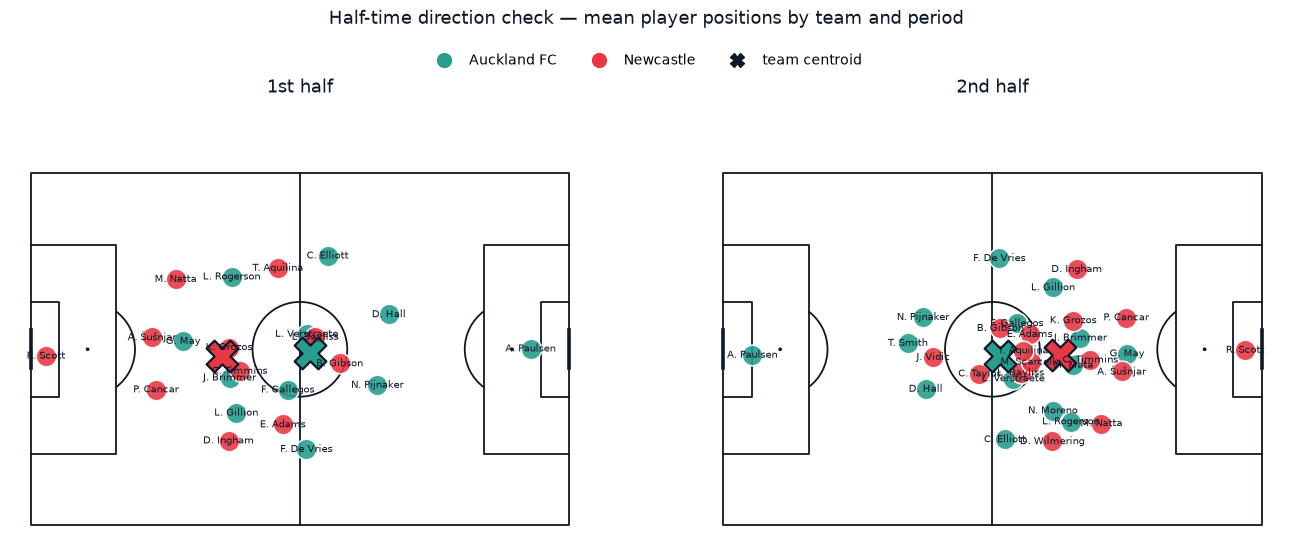

In [ ]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

pos = (
    trk[trk["is_detected"].eq(True)]
    .groupby(["team", "period", "name"], as_index=False)[["x", "y"]]
    .mean()
)

PL = meta["pitch_length"]
PW = meta["pitch_width"]

home = home_team
away = away_team

colors = {
    home: "#2a9d8f",
    away: "#e63946",
}

pitch = Pitch(
    pitch_type="custom",
    pitch_length=PL,
    pitch_width=PW,
    line_color="#0E1726",
    linewidth=1.3,
    pad_top=14,
)

fig, axs = pitch.draw(nrows=1, ncols=2, figsize=(14, 5.2))
axs = axs.flatten() if hasattr(axs, "flatten") else axs

for ax, period in zip(axs, [1, 2]):
    half = pos[pos["period"] == period].copy()

    for team, col in colors.items():
        t = half[half["team"] == team].copy()

        X = t["x"] + PL / 2
        Y = t["y"] + PW / 2

        pitch.scatter(
            X, Y,
            ax=ax,
            s=220,
            color=col,
            edgecolors="white",
            linewidth=1.2,
            alpha=0.9,
            zorder=3,
        )

        pitch.scatter(
            X.mean(), Y.mean(),
            ax=ax,
            s=520,
            marker="X",
            color=col,
            edgecolors="#0E1726",
            linewidth=1.6,
            zorder=4,
        )

        # Oyuncu isimleri
        for _, row in t.iterrows():
            ax.text(
                row["x"] + PL / 2,
                row["y"] + PW / 2,
                row["name"],
                fontsize=7,
                ha="center",
                va="center",
                color="#0E1726",
                zorder=5,
            )

    ax.set_title(
        f"{'1st' if period == 1 else '2nd'} half",
        fontsize=13,
        color="#0E1726",
    )

handles = [
    mlines.Line2D([], [], marker="o", ls="", color=c, markersize=10, label=t)
    for t, c in colors.items()
]
handles.append(
    mlines.Line2D([], [], marker="X", ls="", color="#0E1726", markersize=10, label="team centroid")
)

fig.legend(handles=handles, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.0))

fig.suptitle(
    "Half-time direction check — mean player positions by team and period",
    y=1.06,
    fontsize=13,
    color="#0E1726",
)

plt.tight_layout()
plt.show()

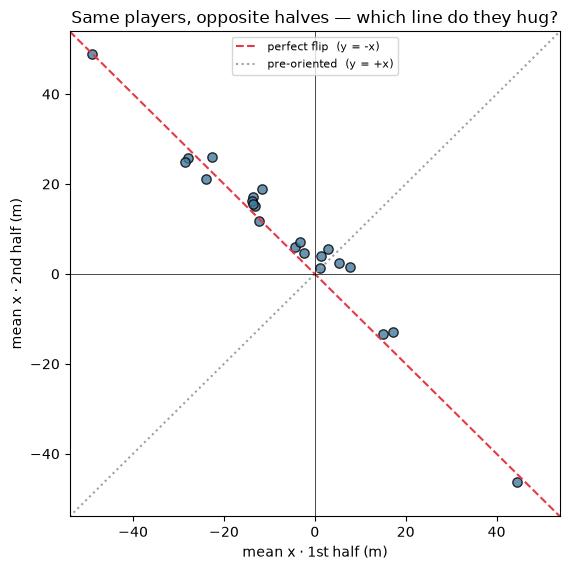

In [ ]:
# =========================
# Half-time direction flip — player mean x in half 1 vs half 2
# =========================

det = trk[trk["is_detected"].eq(True)].copy()

# Aynı oyuncunun 1. ve 2. yarı ortalama x konumu
# player_id_key kullanmak name çakışmalarına karşı daha güvenli
pp = (
    det.pivot_table(
        index=["player_id_key", "name", "team"],
        columns="period",
        values="x",
        aggfunc="mean",
    )
    .dropna()
)

# Sadece 1 ve 2. periodu olanları tutalım
pp = pp[[1, 2]].copy()

lim = float(np.nanmax(np.abs(pp[[1, 2]].values))) * 1.1

fig, ax = plt.subplots(figsize=(5.8, 5.8))

ax.scatter(
    pp[1],
    pp[2],
    s=45,
    color="#457b9d",
    edgecolor="k",
    alpha=0.8,
)

# perfect flip: 2. yarı x = -(1. yarı x)
ax.plot(
    [-lim, lim],
    [lim, -lim],
    ls="--",
    color="#e63946",
    label="perfect flip  (y = -x)",
)

# pre-oriented: 2. yarı x = +(1. yarı x)
ax.plot(
    [-lim, lim],
    [-lim, lim],
    ls=":",
    color="#9aa0a6",
    label="pre-oriented  (y = +x)",
)

ax.axhline(0, color="k", lw=0.5)
ax.axvline(0, color="k", lw=0.5)

ax.set(
    xlim=(-lim, lim),
    ylim=(-lim, lim),
    xlabel="mean x · 1st half (m)",
    ylabel="mean x · 2nd half (m)",
    title="Same players, opposite halves — which line do they hug?",
)

ax.legend(loc="upper center", fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# Simple numeric diagnostic
# =========================

flip_error = np.mean(np.abs(pp[2] + pp[1]))   # y = -x için hata
oriented_error = np.mean(np.abs(pp[2] - pp[1]))  # y = +x için hata

print(f"Mean absolute deviation from y = -x (perfect flip): {flip_error:.2f} m")
print(f"Mean absolute deviation from y = +x (pre-oriented): {oriented_error:.2f} m")

if flip_error < oriented_error:
    print("Conclusion: players hug y = -x more closely → ends switched → we should flip / normalize direction.")
else:
    print("Conclusion: players hug y = +x more closely → data may already be direction-normalized.")

Mean absolute deviation from y = -x (perfect flip): 3.59 m
Mean absolute deviation from y = +x (pre-oriented): 30.14 m
Conclusion: players hug y = -x more closely → ends switched → we should flip / normalize direction.


In [ ]:
from mplsoccer import Sbopen, VerticalPitch
import pandas as pd
import numpy as np

# =========================
# StatsBomb Config
# =========================

SB_COMP_ID = 11        # La Liga
SB_SEASON_ID = 23      # 2011/12
MESSI = "Lionel Andrés Messi Cuccittini"
MATCHES_TO_LOAD = 12   # None = full season

sb = Sbopen()

# =========================
# Load La Liga 2011/12 matches
# =========================

matches = sb.match(
    competition_id=SB_COMP_ID,
    season_id=SB_SEASON_ID
)

barca = matches[
    (matches["home_team_name"] == "Barcelona") |
    (matches["away_team_name"] == "Barcelona")
].copy()

ids = barca["match_id"].tolist()

if MATCHES_TO_LOAD:
    ids = ids[:MATCHES_TO_LOAD]

print(f"Barcelona matches selected: {len(ids)}")
barca.head()

Barcelona matches selected: 12


,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,competition_stage_id,competition_stage_name,stadium_id,stadium_name,stadium_country_id,stadium_country_name,referee_id,referee_name,referee_country_id,referee_country_name
0,70220,2011-09-17,2011-09-17 20:00:00,8,0,available,scheduled,2024-08-08 16:05:15.226901,2021-06-13 16:17:31.694,4,...,1,Regular Season,342,Spotify Camp Nou,214,Spain,997.0,César Muñiz,214.0,Spain
1,69328,2012-02-19,2012-02-19 21:30:00,5,1,available,scheduled,2020-07-29 05:00:00.000000,2021-06-13 16:17:31.694,24,...,1,Regular Season,342,Spotify Camp Nou,214,Spain,1004.0,Turienzo,214.0,Spain
2,69329,2011-10-22,2011-10-22 22:00:00,0,0,available,scheduled,2020-07-29 05:00:00.000000,2021-06-13 16:17:31.694,9,...,1,Regular Season,342,Spotify Camp Nou,214,Spain,999.0,Eduardo Iturralde Gonzalez,214.0,Spain
3,70219,2012-04-07,2012-04-07 20:00:00,1,4,available,scheduled,2020-07-29 05:00:00.000000,2021-06-13 16:17:31.694,32,...,1,Regular Season,4457,Estadio de la Romareda,214,Spain,1004.0,Turienzo,214.0,Spain
4,69331,2011-11-19,2011-11-19 18:00:00,4,0,available,scheduled,2025-06-24 09:49:17.824908,2021-06-13 16:17:31.694,13,...,1,Regular Season,342,Spotify Camp Nou,214,Spain,221.0,Alberto Undiano Mallenco,214.0,Spain


In [ ]:
# =========================
# Load Messi shots
# =========================

shots_list = []

for match_id in ids:
    ev, related, freeze, tactics = sb.event(match_id)

    messi_shots = ev[
        (ev["type_name"] == "Shot") &
        (ev["player_name"] == MESSI)
    ].copy()

    messi_shots["match_id"] = match_id
    shots_list.append(messi_shots)

shots = pd.concat(shots_list, ignore_index=True)

goals = shots[shots["outcome_name"] == "Goal"].copy()

xg = shots["shot_statsbomb_xg"].sum()

print(f"Messi · La Liga 2011/12 · {len(ids)} matches loaded")
print(
    f"shots {len(shots)} | "
    f"goals {len(goals)} | "
    f"xG {xg:.1f} | "
    f"finishing (G-xG) {len(goals) - xg:+.1f}"
)

shots.head()

Messi · La Liga 2011/12 · 12 matches loaded
shots 75 | goals 22 | xG 13.9 | finishing (G-xG) +8.1


,id,index,period,timestamp,minute,second,possession,duration,match_id,type_id,...,pass_no_touch,pass_cut_back,dribble_nutmeg,pass_deflected,foul_committed_penalty,foul_won_penalty,block_save_block,injury_stoppage_in_chain,shot_follows_dribble,shot_deflected
0,dc8d7b2e-63db-40c1-81d4-e36958199625,227,1,00:04:16.874000,4,16,8,0.438300,70220,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,c31e016f-e6c5-44f2-a6b6-db2158700034,328,1,00:07:05.497000,7,5,14,0.507800,70220,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,dc2049bd-dcb9-4a74-9b44-e7551fbf454d,1412,1,00:29:30.650000,29,30,58,0.188186,70220,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4d1822cf-9585-4a59-9915-618b7049d173,1789,1,00:40:26.800000,40,26,74,0.756200,70220,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2477bd3a-f996-4936-9efc-bea8ff64f16c,2219,2,00:05:00.616000,50,0,90,0.944300,70220,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


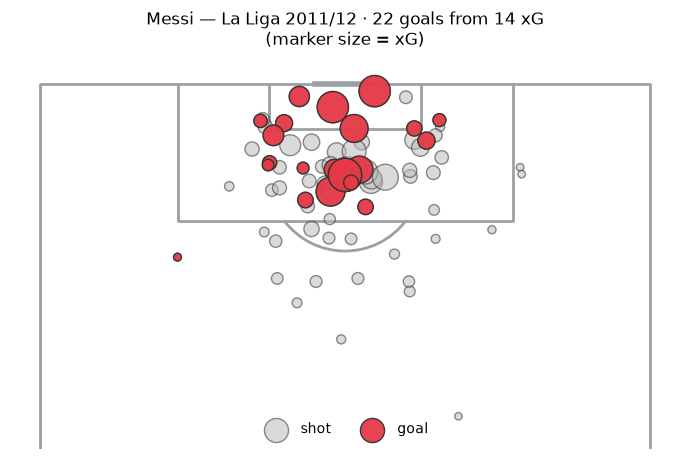

shots 75 | goals 22 | xG 13.9 | G-xG +8.1 | xG/shot 0.18


In [ ]:
from mplsoccer import VerticalPitch
import matplotlib.pyplot as plt

# =========================
# Messi Shot Map — La Liga 2011/12
# =========================

shots = shots.copy()
goals = shots[shots["outcome_name"] == "Goal"].copy()

total_shots = len(shots)
total_goals = len(goals)
total_xg = shots["shot_statsbomb_xg"].sum()
goals_minus_xg = total_goals - total_xg
avg_xg_per_shot = shots["shot_statsbomb_xg"].mean()

pitch = VerticalPitch(
    pitch_type="statsbomb",
    half=True,
    pad_bottom=-12,
    line_color="#9aa0a6"
)

fig, ax = pitch.draw(figsize=(7, 7))

# All shots
pitch.scatter(
    shots["x"],
    shots["y"],
    ax=ax,
    c="#bdbdbd",
    edgecolors="#333333",
    s=shots["shot_statsbomb_xg"] * 700 + 25,
    alpha=0.55,
    label="shot",
)

# Goals
pitch.scatter(
    goals["x"],
    goals["y"],
    ax=ax,
    c="#e63946",
    edgecolors="#333333",
    s=goals["shot_statsbomb_xg"] * 700 + 25,
    alpha=0.95,
    label="goal",
)

ax.set_title(
    f"Messi — La Liga 2011/12 · {total_goals} goals from {total_xg:.0f} xG\n"
    f"(marker size = xG)",
    fontsize=12,
)

ax.legend(
    loc="lower center",
    ncol=2,
    frameon=False,
)

plt.tight_layout()
plt.show()

print(
    f"shots {total_shots} | "
    f"goals {total_goals} | "
    f"xG {total_xg:.1f} | "
    f"G-xG {goals_minus_xg:+.1f} | "
    f"xG/shot {avg_xg_per_shot:.2f}"
)

In [20]:
# =========================
# Cell 1 — Sanity Check
# =========================

import os
import numpy as np
import pandas as pd

if "trk" not in globals():
    raise NameError("`trk` dataframe is not defined. First parse SkillCorner tracking data into `trk`.")

if "FPS" not in globals():
    FPS = 10
    print("FPS was not defined. Using default FPS = 10.")

required_trk_cols = [
    "frame",
    "period",
    "player_id",
    "x",
    "y",
    "is_detected",
    "minute",
    "player_id_key",
    "name",
    "team",
]

missing_cols = [col for col in required_trk_cols if col not in trk.columns]

if missing_cols:
    raise ValueError(f"`trk` is missing required columns: {missing_cols}")

print("Ready.")
print(f"trk shape: {trk.shape}")
print(f"FPS: {FPS}")
print(f"Detected pct: {trk['is_detected'].eq(True).mean():.1%}")
print(f"Extrapolated pct: {trk['is_detected'].eq(False).mean():.1%}")

Ready.
trk shape: (956076, 10)
FPS: 10
Detected pct: 59.3%
Extrapolated pct: 40.7%


In [21]:
# =========================
# Cell 2 — Gemini LLM Caller
# =========================

import os

PROVIDER = "gemini"
MODEL = "gemini-2.5-flash"
KEY_ENV = "GOOGLE_API_KEY"


def call_llm(system: str, user: str, fallback: str = "") -> str:
    """
    Call Gemini 2.5 Flash.

    If the API key is missing or the call fails, return fallback text.
    This makes the live demo safe.
    """
    key = os.environ.get(KEY_ENV)

    if not key:
        print(f"(no {KEY_ENV} set — showing cached output)\n")
        return fallback

    try:
        from google import genai

        client = genai.Client(api_key=key)

        response = client.models.generate_content(
            model=MODEL,
            contents=user,
            config={
                "system_instruction": system,
                "temperature": 0.2,
            },
        )

        return response.text

    except Exception as e:
        print(f"(live call failed: {e} — showing cached output)\n")
        return fallback


print("call_llm is ready.")

call_llm is ready.


In [22]:
# =========================
# Cell 3 — Data-Janitor Profile Generator
# =========================

def profile_tracking_df(df: pd.DataFrame, fps: int = 10) -> str:
    """
    Build a compact, evidence-rich profile for a football broadcast tracking dataframe.

    The profile is designed for a Data-Janitor Agent.
    It summarizes:
    - detected vs extrapolated positions
    - player ID quality
    - coordinate ranges
    - coverage over time
    - team/period mean x
    - half-time direction flip signal
    - player visibility problems
    """

    required_cols = [
        "frame",
        "period",
        "player_id",
        "x",
        "y",
        "is_detected",
        "minute",
        "player_id_key",
        "name",
        "team",
    ]

    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        raise ValueError(f"Missing required columns in tracking dataframe: {missing_cols}")

    detected_rate = df["is_detected"].eq(True).mean()
    extrapolated_rate = df["is_detected"].eq(False).mean()
    unmapped_rate = df["name"].eq("unmapped").mean()
    missing_xy_rate = df[["x", "y"]].isna().any(axis=1).mean()

    coverage_by_frame = (
        df.groupby("frame")["is_detected"]
        .mean()
        .sort_index()
    )

    coverage_by_minute = (
        coverage_by_frame
        .groupby(np.floor(coverage_by_frame.index / fps / 60).astype(int))
        .mean()
    )

    mean_x_by_team_period = (
        df[df["is_detected"].eq(True)]
        .groupby(["team", "period"])["x"]
        .mean()
        .unstack("period")
    )

    player_visibility_profile = (
        df
        .groupby(["team", "name", "player_id_key"], dropna=False)
        .agg(
            player_frames=("frame", "size"),
            unique_frames=("frame", "nunique"),
            detected_pct=("is_detected", lambda s: s.eq(True).mean()),
            extrapolated_pct=("is_detected", lambda s: s.eq(False).mean()),
            first_minute=("minute", "min"),
            last_minute=("minute", "max"),
            mean_x=("x", "mean"),
            mean_y=("y", "mean"),
        )
        .reset_index()
    )

    most_extrapolated_players = (
        player_visibility_profile
        .sort_values(["extrapolated_pct", "player_frames"], ascending=[False, False])
        .head(8)
    )

    most_visible_players = (
        player_visibility_profile[player_visibility_profile["player_frames"] >= 3000]
        .sort_values(["detected_pct", "player_frames"], ascending=[False, False])
        .head(8)
    )

    detected_df = df[df["is_detected"].eq(True)].copy()

    pp = (
        detected_df
        .pivot_table(
            index=["player_id_key", "name", "team"],
            columns="period",
            values="x",
            aggfunc="mean",
        )
        .dropna()
    )

    if 1 in pp.columns and 2 in pp.columns and len(pp) > 0:
        pp = pp[[1, 2]].copy()

        flip_error = np.mean(np.abs(pp[2] + pp[1]))       # y = -x
        oriented_error = np.mean(np.abs(pp[2] - pp[1]))   # y = +x

        if flip_error < oriented_error:
            flip_diagnosis = (
                f"Players are closer to y=-x than y=+x "
                f"(flip_error={flip_error:.2f}m, oriented_error={oriented_error:.2f}m). "
                f"This suggests teams swap ends at half-time and second-half coordinates likely need normalization."
            )
        else:
            flip_diagnosis = (
                f"Players are closer to y=+x than y=-x "
                f"(flip_error={flip_error:.2f}m, oriented_error={oriented_error:.2f}m). "
                f"This suggests the feed may already be direction-normalized."
            )
    else:
        flip_diagnosis = (
            "Could not compute per-player half-time direction diagnostic. "
            "Period 1 and/or period 2 data is missing."
        )

    profile = f"""
TRACKING DATAFRAME PROFILE

Shape:
- {df.shape[0]:,} rows x {df.shape[1]:,} columns

Columns and dtypes:
{df.dtypes.to_string()}

Core coverage:
- detected positions: {detected_rate:.1%}
- extrapolated positions: {extrapolated_rate:.1%}
- missing x/y coordinates: {missing_xy_rate:.1%}
- unmapped player ids: {unmapped_rate:.1%}
- unique player ids: {df["player_id_key"].nunique():,}
- unique frames: {df["frame"].nunique():,}
- FPS assumed: {fps}

Coordinate ranges:
- x range: [{df["x"].min():.2f}, {df["x"].max():.2f}]
- y range: [{df["y"].min():.2f}, {df["y"].max():.2f}]

Broadcast coverage over time:
- mean detected share per frame: {coverage_by_frame.mean():.1%}
- min detected share per minute: {coverage_by_minute.min():.1%}
- max detected share per minute: {coverage_by_minute.max():.1%}

Mean detected x by team and period:
{mean_x_by_team_period.to_string()}

Half-time direction diagnostic:
{flip_diagnosis}

Most extrapolated players:
{most_extrapolated_players[["team", "name", "player_frames", "detected_pct", "extrapolated_pct"]].to_string(index=False)}

Most visible players:
{most_visible_players[["team", "name", "player_frames", "detected_pct", "extrapolated_pct"]].to_string(index=False)}

Sample rows:
{df.head(6).to_string(index=False)}
""".strip()

    return profile


print("profile_tracking_df is ready.")

profile_tracking_df is ready.


In [23]:
# =========================
# Cell 4 — Data-Janitor System Prompt
# =========================

JANITOR_SYSTEM = """
You are a senior football tracking-data engineer and football analytics consultant.

You are given a compact profile of a BROADCAST tracking dataframe named `trk`.

Context:
- This is broadcast tracking data, not optical in-stadium tracking.
- Player coordinates are computer-vision derived.
- `is_detected=True` means the player was actually seen by the camera.
- `is_detected=False` means the position was extrapolated/model-filled, not directly measured.
- Coordinates appear to be centre-origin: x=0 and y=0 are around the middle of the pitch.
- The dataframe may be used later for distance, speed, acceleration, spacing, off-ball movement, and tactical shape.
- Those metrics are highly sensitive to extrapolation, ID errors, direction flips, and raw x/y jitter.

Your task:
Diagnose the data quality risks and propose safe cleaning steps.

Respond in exactly four sections:

1) ISSUES
- Rank the issues by severity.
- Each issue must cite specific evidence from the profile.
- Be football-aware: explain why the issue matters for football metrics.

2) CLEANING PLAN
- Give a short ordered plan.
- Separate "safe default steps" from "conditional steps".
- Be explicit when a step should only happen after a diagnostic confirms it.

3) RUNNABLE PANDAS CODE
- Provide code assuming the dataframe is called `trk`.
- Do not mutate `trk` directly. Create `trk_clean = trk.copy()`.
- Do not invent columns that are not in the profile.
- Use only pandas/numpy.
- Include comments.
- Preserve `is_detected`; do not delete it.
- For direction normalization, only apply the flip if the per-player half-time diagnostic supports y=-x.
- For smoothing, sort by player and frame first.
- Do not compute speed/acceleration unless you first smooth or explicitly flag the risk.

4) DO-NOT
- One concise warning about a tempting but wrong cleaning decision that would corrupt football analysis.

Style:
- Be concrete.
- Be concise.
- No generic data-cleaning advice.
- No invented assumptions.
- If a decision depends on provider behavior, say so.
"""

print("JANITOR_SYSTEM is ready.")

JANITOR_SYSTEM is ready.


In [27]:
# =========================
# Cell 5 — Data-Janitor Fallback Output
# =========================

pm = trk[trk["is_detected"].eq(True)].groupby("period")["x"].mean()
p1 = pm.get(1, float("nan"))
p2 = pm.get(2, float("nan"))

extrapolated_rate = trk["is_detected"].eq(False).mean()
detected_rate = trk["is_detected"].eq(True).mean()
unmapped_rate = trk["name"].eq("unmapped").mean()
missing_xy_rate = trk[["x", "y"]].isna().any(axis=1).mean()

janitor_fallback = f"""
1) ISSUES

1. Extrapolated tracking is the main risk: {extrapolated_rate:.0%} of player positions are not directly observed. Distance, speed, acceleration, spacing, and off-ball movement can become partly model-generated if `is_detected` is ignored.

2. Half-time direction needs explicit validation: detected mean x by period is {p1:+.1f}m → {p2:+.1f}m. Team averages can hide the end-switch, so the per-player half 1 vs half 2 diagnostic should decide whether to flip.

3. Identity mapping is clean in this match: {unmapped_rate:.0%} unmapped rows. Still, this should be re-checked every match before player-level aggregation.

4. Missing coordinates are not the issue here: {missing_xy_rate:.0%} rows have missing x/y. The issue is quality of observation, not coordinate availability.

5. Raw x/y tracking can contain computer-vision jitter. Any speed or acceleration metric should be computed only after sorting and smoothing trajectories.

2) CLEANING PLAN

Safe default steps:
- Keep `is_detected` as a first-class quality flag.
- Preserve raw coordinates for auditability.
- Create detected-only views for physical metrics.
- Remove or flag unmapped players if they appear.
- Sort by player and frame before any trajectory operation.
- Smooth x/y before speed or acceleration.

Conditional steps:
- Only normalize second-half coordinates if the per-player half-time diagnostic shows points closer to y=-x than y=+x.
- Do not blindly flip every provider; some feeds are already pre-oriented.

3) RUNNABLE PANDAS CODE

import numpy as np
import pandas as pd

trk_clean = trk.copy()

# Preserve raw coordinates for auditability
trk_clean["x_raw"] = trk_clean["x"]
trk_clean["y_raw"] = trk_clean["y"]

# Optional direction normalization.
# Apply only if the per-player half-time diagnostic confirms y=-x.
SHOULD_FLIP_SECOND_HALF = True

if SHOULD_FLIP_SECOND_HALF:
    mask_second_half = trk_clean["period"].eq(2)
    trk_clean.loc[mask_second_half, ["x", "y"]] = (
        trk_clean.loc[mask_second_half, ["x", "y"]] * -1
    )

# Safe physical-metrics view: use only directly detected positions
trk_detected = (
    trk_clean[
        trk_clean["is_detected"].eq(True)
        & trk_clean["name"].ne("unmapped")
        & trk_clean[["x", "y"]].notna().all(axis=1)
    ]
    .sort_values(["player_id_key", "frame"])
    .copy()
)

# Smooth trajectories before derivative metrics such as speed/acceleration
WINDOW = 5

trk_detected[["x_smooth", "y_smooth"]] = (
    trk_detected
    .groupby("player_id_key")[["x", "y"]]
    .transform(lambda s: s.rolling(WINDOW, center=True, min_periods=1).mean())
)

quality_summary = pd.Series({{
    "rows": len(trk_clean),
    "detected_pct": trk_clean["is_detected"].eq(True).mean(),
    "extrapolated_pct": trk_clean["is_detected"].eq(False).mean(),
    "unmapped_pct": trk_clean["name"].eq("unmapped").mean(),
    "missing_xy_pct": trk_clean[["x", "y"]].isna().any(axis=1).mean(),
}})

4) DO-NOT

Do not interpolate across extrapolated gaps and then report distance covered as if it were measured; that would measure the tracker's guesses, not the player.
"""

print("janitor_fallback is ready.")

janitor_fallback is ready.


In [28]:
janitor_profile = profile_tracking_df(trk, fps=FPS)

janitor_user = (
    "Here is the profile of my SkillCorner broadcast tracking dataframe `trk`.\n\n"
    "Diagnose the tracking-data problems and write safe cleaning code.\n\n"
    + janitor_profile
)

print("janitor_user is ready.")
print(janitor_user[:3000])

janitor_user is ready.
Here is the profile of my SkillCorner broadcast tracking dataframe `trk`.

Diagnose the tracking-data problems and write safe cleaning code.

TRACKING DATAFRAME PROFILE

Shape:
- 956,076 rows x 10 columns

Columns and dtypes:
frame              int64
period             int64
player_id          int64
x                float64
y                float64
is_detected         bool
minute           float64
player_id_key        str
name                 str
team                 str

Core coverage:
- detected positions: 59.3%
- extrapolated positions: 40.7%
- missing x/y coordinates: 0.0%
- unmapped player ids: 0.0%
- unique player ids: 29
- unique frames: 43,458
- FPS assumed: 10

Coordinate ranges:
- x range: [-57.05, 58.27]
- y range: [-37.14, 37.16]

Broadcast coverage over time:
- mean detected share per frame: 59.3%
- min detected share per minute: 3.9%
- max detected share per minute: 81.0%

Mean detected x by team and period:
period               1          2
team   

In [31]:
from pathlib import Path
import json
import pandas as pd

PROJECT_ROOT = Path.cwd()

STATSBOMB_DIR = PROJECT_ROOT / "open-data-master" / "data"
SB_EVENTS_DIR = STATSBOMB_DIR / "events"
SB_MATCHES_DIR = STATSBOMB_DIR / "matches"

SB_COMP_ID = 11
SB_SEASON_ID = 23
MESSI = "Lionel Andrés Messi Cuccittini"
MATCHES_TO_LOAD = 12

print("StatsBomb path:", STATSBOMB_DIR)

StatsBomb path: c:\Users\musta\OneDrive\Desktop\Messi Analytics Project\open-data-master\data


In [32]:
SB_MATCH_FILE = SB_MATCHES_DIR / str(SB_COMP_ID) / f"{SB_SEASON_ID}.json"

if not SB_MATCH_FILE.exists():
    raise FileNotFoundError(f"StatsBomb match file not found: {SB_MATCH_FILE}")

with open(SB_MATCH_FILE, "r", encoding="utf-8") as f:
    matches_raw = json.load(f)

matches = pd.json_normalize(matches_raw)

print("Matches loaded:", matches.shape)
matches.head()

Matches loaded: (37, 42)


,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,competition_stage.id,competition_stage.name,stadium.id,stadium.name,stadium.country.id,stadium.country.name,referee.id,referee.name,referee.country.id,referee.country.name
0,70220,2011-09-17,20:00:00.000,8,0,available,scheduled,2024-08-08T16:05:15.226901,2021-06-13T16:17:31.694,4,...,1,Regular Season,342,Spotify Camp Nou,214,Spain,997.0,César Muñiz,214.0,Spain
1,69328,2012-02-19,21:30:00.000,5,1,available,scheduled,2020-07-29T05:00,2021-06-13T16:17:31.694,24,...,1,Regular Season,342,Spotify Camp Nou,214,Spain,1004.0,Turienzo,214.0,Spain
2,69329,2011-10-22,22:00:00.000,0,0,available,scheduled,2020-07-29T05:00,2021-06-13T16:17:31.694,9,...,1,Regular Season,342,Spotify Camp Nou,214,Spain,999.0,Eduardo Iturralde Gonzalez,214.0,Spain
3,70219,2012-04-07,20:00:00.000,1,4,available,scheduled,2020-07-29T05:00,2021-06-13T16:17:31.694,32,...,1,Regular Season,4457,Estadio de la Romareda,214,Spain,1004.0,Turienzo,214.0,Spain
4,69331,2011-11-19,18:00:00.000,4,0,available,scheduled,2025-06-24T09:49:17.824908,2021-06-13T16:17:31.694,13,...,1,Regular Season,342,Spotify Camp Nou,214,Spain,221.0,Alberto Undiano Mallenco,214.0,Spain


In [33]:
print(matches.columns.tolist())

['match_id', 'match_date', 'kick_off', 'home_score', 'away_score', 'match_status', 'match_status_360', 'last_updated', 'last_updated_360', 'match_week', 'competition.competition_id', 'competition.country_name', 'competition.competition_name', 'season.season_id', 'season.season_name', 'home_team.home_team_id', 'home_team.home_team_name', 'home_team.home_team_gender', 'home_team.home_team_group', 'home_team.country.id', 'home_team.country.name', 'home_team.managers', 'away_team.away_team_id', 'away_team.away_team_name', 'away_team.away_team_gender', 'away_team.away_team_group', 'away_team.country.id', 'away_team.country.name', 'away_team.managers', 'metadata.data_version', 'metadata.shot_fidelity_version', 'metadata.xy_fidelity_version', 'competition_stage.id', 'competition_stage.name', 'stadium.id', 'stadium.name', 'stadium.country.id', 'stadium.country.name', 'referee.id', 'referee.name', 'referee.country.id', 'referee.country.name']


In [34]:
home_col = "home_team.home_team_name"
away_col = "away_team.away_team_name"

barca = matches[
    matches[home_col].eq("Barcelona")
    | matches[away_col].eq("Barcelona")
].copy()

ids = barca["match_id"].tolist()

if MATCHES_TO_LOAD is not None:
    ids = ids[:MATCHES_TO_LOAD]

print(f"Barcelona matches selected: {len(ids)}")
print(ids[:5])

Barcelona matches selected: 12
[70220, 69328, 69329, 70219, 69331]


In [35]:
shots_list = []

for match_id in ids:
    event_file = SB_EVENTS_DIR / f"{match_id}.json"

    if not event_file.exists():
        print(f"Warning: event file missing for match {match_id}")
        continue

    with open(event_file, "r", encoding="utf-8") as f:
        events_raw = json.load(f)

    ev = pd.json_normalize(events_raw)

    required_cols = [
        "type.name",
        "player.name",
        "shot.outcome.name",
        "shot.statsbomb_xg",
        "location",
    ]

    missing = [col for col in required_cols if col not in ev.columns]
    if missing:
        raise ValueError(
            f"Missing columns in match {match_id}: {missing}"
        )

    messi_shots = ev[
        ev["type.name"].eq("Shot")
        & ev["player.name"].eq(MESSI)
    ].copy()

    if messi_shots.empty:
        continue

    messi_shots["match_id"] = match_id

    # StatsBomb location = [x, y]
    messi_shots["x"] = messi_shots["location"].apply(
        lambda value: value[0] if isinstance(value, list) and len(value) >= 2 else None
    )
    messi_shots["y"] = messi_shots["location"].apply(
        lambda value: value[1] if isinstance(value, list) and len(value) >= 2 else None
    )

    shots_list.append(messi_shots)

if not shots_list:
    raise ValueError(
        "No Messi shots found. Check the player name and selected matches."
    )

shots = pd.concat(shots_list, ignore_index=True)

goals = shots[shots["shot.outcome.name"].eq("Goal")].copy()
xg = shots["shot.statsbomb_xg"].sum()

print(f"Messi · La Liga 2011/12 · {len(ids)} matches loaded")
print(
    f"shots {len(shots)} | "
    f"goals {len(goals)} | "
    f"xG {xg:.1f} | "
    f"finishing (G-xG) {len(goals) - xg:+.1f}"
)

Messi · La Liga 2011/12 · 12 matches loaded
shots 75 | goals 22 | xG 13.9 | finishing (G-xG) +8.1


In [36]:
shots = shots.rename(
    columns={
        "shot.outcome.name": "outcome_name",
        "shot.statsbomb_xg": "shot_statsbomb_xg",
        "player.name": "player_name",
        "type.name": "type_name",
    }
)

goals = shots[shots["outcome_name"].eq("Goal")].copy()
xg = shots["shot_statsbomb_xg"].sum()

print("Standardized columns ready.")
print(
    f"shots {len(shots)} | "
    f"goals {len(goals)} | "
    f"xG {xg:.1f} | "
    f"G-xG {len(goals) - xg:+.1f}"
)

shots[
    [
        "match_id",
        "player_name",
        "type_name",
        "outcome_name",
        "shot_statsbomb_xg",
        "x",
        "y",
    ]
].head()

Standardized columns ready.
shots 75 | goals 22 | xG 13.9 | G-xG +8.1


,match_id,player_name,type_name,outcome_name,shot_statsbomb_xg,x,y
0,70220,Lionel Andrés Messi Cuccittini,Shot,Goal,0.689756,116.9,38.4
1,70220,Lionel Andrés Messi Cuccittini,Shot,Saved,0.099668,103.9,35.1
2,70220,Lionel Andrés Messi Cuccittini,Shot,Post,0.218658,111.0,38.9
3,70220,Lionel Andrés Messi Cuccittini,Shot,Goal,0.273771,108.7,38.6
4,70220,Lionel Andrés Messi Cuccittini,Shot,Post,0.104451,108.3,51.6


In [37]:
print("ids" in globals())
print("shots" in globals())
print("goals" in globals())
print("xg" in globals())

True
True
True
True


In [38]:
# =========================
# Cell 1 — Build Messi Statistics Block
# =========================

required_variables = ["ids", "shots", "goals", "xg"]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise NameError(
        f"Missing required variables: {missing_variables}. "
        "First load the StatsBomb Messi shots."
    )

required_shot_columns = [
    "x",
    "shot_statsbomb_xg",
    "outcome_name",
]

missing_columns = [
    column
    for column in required_shot_columns
    if column not in shots.columns
]

if missing_columns:
    raise ValueError(
        f"`shots` is missing required columns: {missing_columns}"
    )

if len(ids) == 0:
    raise ValueError("No Barcelona matches were loaded.")

if len(shots) == 0:
    raise ValueError("No Messi shots were found.")

sample_matches = len(ids)
total_shots = len(shots)
total_goals = len(goals)
total_xg = float(xg)

finishing_over_expected = total_goals - total_xg
goals_per_match = total_goals / sample_matches
average_xg_per_shot = shots["shot_statsbomb_xg"].mean()
inside_box_share = shots["x"].gt(102).mean()

messi_stats = (
    f"Player: Lionel Messi\n"
    f"Competition/season: La Liga 2011/12\n"
    f"Sample size: {sample_matches} Barcelona matches\n"
    f"Shots: {total_shots}\n"
    f"Goals: {total_goals}\n"
    f"Total xG: {total_xg:.1f}\n"
    f"Goals minus xG: {finishing_over_expected:+.1f}\n"
    f"Goals per sampled match: {goals_per_match:.2f}\n"
    f"Average xG per shot: {average_xg_per_shot:.3f}\n"
    f"Share of shots from inside the penalty box, using x > 102: "
    f"{inside_box_share:.0%}\n"
    f"Important limitation: these figures cover only the loaded "
    f"{sample_matches}-match sample, not necessarily the entire league season."
)

print(messi_stats)

Player: Lionel Messi
Competition/season: La Liga 2011/12
Sample size: 12 Barcelona matches
Shots: 75
Goals: 22
Total xG: 13.9
Goals minus xG: +8.1
Goals per sampled match: 1.83
Average xG per shot: 0.185
Share of shots from inside the penalty box, using x > 102: 77%
Important limitation: these figures cover only the loaded 12-match sample, not necessarily the entire league season.


In [39]:
# =========================
# Cell 2 — Wordalisation Agent System Prompt
# =========================

WORDALISER_SYSTEM = """
You are a senior football analytics translator working inside a professional club.

Your task is to transform one block of measured player statistics into three
audience-specific registers without changing the underlying evidence.

You must produce exactly these three clearly labelled sections:

1) COACH
- Write for a first-team coach preparing the next training week.
- Use present-tense, football-specific and actionable language.
- Focus on shot selection, chance locations, attacking patterns and tactical usage.
- Explain what the measured profile suggests should be reinforced.
- Do not invent opponents, match situations, tactical formations or causal explanations.

2) SCOUT
- Write for a recruitment scout.
- Describe the player profile signalled by the measurements.
- Focus on shot volume, chance quality, scoring output and finishing relative to xG.
- Distinguish observed production from claims about future sustainability.
- Do not compare the player with unnamed league averages or other players unless
  comparative benchmark data is explicitly provided.

3) SPORTING DIRECTOR
- Write for a sporting director or board-level decision-maker.
- Frame the evidence in terms of sporting value, uncertainty and decision risk.
- Mention sample-size limitations where material.
- Do not invent transfer value, salary, commercial impact, contract demands,
  availability, age trajectory or injury risk.

Grounding rules:
- Use only the numbers and definitions supplied by the user.
- Do not invent events, opponents, assists, touches, shot body parts, shot angles,
  defensive pressure, game states or tactical causes.
- Do not describe a metric as league-leading, elite, exceptional or repeatable
  unless the supplied data provides an explicit benchmark or longitudinal evidence.
- A strongly positive Goals-minus-xG figure may be described as strong finishing
  overperformance within this sample.
- Do not automatically claim that positive Goals-minus-xG will persist.
- Treat the inside-box percentage according to its exact value; do not say
  "almost all" unless the percentage reasonably supports that wording.
- Keep goals per match tied explicitly to the sampled matches.
- Preserve the distinction between measured fact, interpretation and uncertainty.

Output requirements:
- Each section should contain approximately three concise sentences.
- Include the most relevant numbers naturally rather than listing every metric.
- Use clear professional English suitable for a football club.
- Do not include markdown tables.
- Do not add an introduction or conclusion outside the three sections.
"""
 
print("WORDALISER_SYSTEM is ready.")

WORDALISER_SYSTEM is ready.


In [40]:
# =========================
# Cell 3 — Wordalisation Fallback Output
# =========================

inside_box_wording = (
    "most of his shots come from inside the penalty box"
    if inside_box_share >= 0.70
    else
    "a meaningful share of his shots comes from inside the penalty box"
    if inside_box_share >= 0.50
    else
    "less than half of his shots come from inside the penalty box"
)

word_fallback = f"""
COACH

Across the {sample_matches}-match sample, Messi records {total_goals} goals from
{total_shots} shots and {total_xg:.1f} xG. At {average_xg_per_shot:.2f} xG per
shot, with {inside_box_share:.0%} of attempts from inside the penalty box, the
measured profile supports reinforcing attacking patterns that deliver him into
valuable shooting areas. His {finishing_over_expected:+.1f} Goals-minus-xG shows
strong finishing overperformance within this sample, but it should not replace
the process of consistently creating good chances.

SCOUT

The sample describes a high-output scorer producing {goals_per_match:.2f} goals
per loaded match from {average_xg_per_shot:.2f} xG per shot. {inside_box_wording.capitalize()},
while the {finishing_over_expected:+.1f} Goals-minus-xG indicates that actual
scoring substantially exceeds the estimated chance value in these matches.
This is strong evidence of finishing overperformance in the sample, although
sustainability would require a larger and preferably multi-season benchmark.

SPORTING DIRECTOR

The measured return is {total_goals} goals from {total_xg:.1f} xG across
{sample_matches} sampled matches, equivalent to {goals_per_match:.2f} goals per
sampled match. That production represents substantial sporting value, while
the positive Goals-minus-xG should be separated from the repeatable value of the
underlying chance volume and quality. Any board-level decision should therefore
combine this output with the full-season record, multiple seasons and appropriate
comparison groups rather than treating this sample alone as a complete valuation.
""".strip()

print("word_fallback is ready.")

word_fallback is ready.


In [41]:
# =========================
# Cell 4 — Build Wordalisation User Prompt
# =========================

wordaliser_user = (
    "Translate the following measured football outputs into the three required "
    "club registers.\n\n"
    "Do not calculate or introduce any statistic that is not already supplied.\n"
    "Keep every conclusion explicitly tied to this sample.\n\n"
    + messi_stats
)

print("wordaliser_user is ready.")
print("-" * 80)
print(wordaliser_user)

wordaliser_user is ready.
--------------------------------------------------------------------------------
Translate the following measured football outputs into the three required club registers.

Do not calculate or introduce any statistic that is not already supplied.
Keep every conclusion explicitly tied to this sample.

Player: Lionel Messi
Competition/season: La Liga 2011/12
Sample size: 12 Barcelona matches
Shots: 75
Goals: 22
Total xG: 13.9
Goals minus xG: +8.1
Goals per sampled match: 1.83
Average xG per shot: 0.185
Share of shots from inside the penalty box, using x > 102: 77%
Important limitation: these figures cover only the loaded 12-match sample, not necessarily the entire league season.


In [42]:
# =========================
# Cell 5 — Run Wordalisation Agent
# =========================

wordaliser_output = call_llm(
    system=WORDALISER_SYSTEM,
    user=wordaliser_user,
    fallback=word_fallback,
)

print(wordaliser_output)

1) COACH
Messi consistently takes high-quality shots, with 77% of his 75 attempts in this sample coming from inside the penalty box, yielding an average xG of 0.185 per shot. We should reinforce attacking patterns that continue to generate these preferred inside-box shooting locations, leveraging his strong finishing ability. His current output of 1.83 goals per sampled match, significantly overperforming his 13.9 xG, demonstrates the effectiveness of his shot selection and execution.

2) SCOUT
This 12-match sample reveals a player profile with high shot volume (75 shots) and strong chance quality, evidenced by 77% of shots originating from inside the penalty box and an average xG per shot of 0.185. His scoring output is very high, with 22 goals from 13.9 xG, translating to 1.83 goals per sampled match. The +8.1 Goals-minus-xG indicates strong finishing overperformance within this specific sample.

3) SPORTING DIRECTOR
The player's output in this 12-match sample demonstrates exceptiona

In [ ]:
# =========================
# Cell 1 — Standardize Shot Sub-Type
# =========================

possible_subtype_columns = [
    "sub_type_name",      
    "shot.type.name",     
    "shot_type_name",
]

available_subtype_column = next(
    (col for col in possible_subtype_columns if col in shots.columns),
    None,
)

if available_subtype_column is None:
    raise ValueError(
        "No shot subtype column found. Expected one of: "
        f"{possible_subtype_columns}"
    )

if available_subtype_column != "sub_type_name":
    shots["sub_type_name"] = shots[available_subtype_column]

print(f"Shot subtype source: {available_subtype_column}")
print(shots["sub_type_name"].value_counts(dropna=False))

Shot subtype source: shot.type.name
sub_type_name
Open Play    59
Free Kick    13
Penalty       3
Name: count, dtype: int64


In [44]:
# =========================
# Cell 2 — Penalty vs Non-Penalty Split
# =========================

required_columns = [
    "sub_type_name",
    "outcome_name",
    "shot_statsbomb_xg",
]

missing_columns = [
    col for col in required_columns
    if col not in shots.columns
]

if missing_columns:
    raise ValueError(
        f"`shots` is missing required columns: {missing_columns}"
    )

pen = shots[shots["sub_type_name"].eq("Penalty")].copy()
op = shots[~shots["sub_type_name"].eq("Penalty")].copy()

pen_goals = int(pen["outcome_name"].eq("Goal").sum())
op_goals = int(op["outcome_name"].eq("Goal").sum())

pen_xg = float(pen["shot_statsbomb_xg"].sum())
op_xg = float(op["shot_statsbomb_xg"].sum())

op_fin = op_goals - op_xg

n_fk = int(shots["sub_type_name"].eq("Free Kick").sum())

print("Penalty split ready.")
print(
    f"Penalties: {len(pen)} shots | "
    f"{pen_goals} goals | "
    f"{pen_xg:.1f} xG"
)
print(
    f"Non-penalties: {len(op)} shots | "
    f"{op_goals} goals | "
    f"{op_xg:.1f} xG | "
    f"G-xG {op_fin:+.1f}"
)
print(f"Free-kick shots: {n_fk}")

Penalty split ready.
Penalties: 3 shots | 2 goals | 2.4 xG
Non-penalties: 72 shots | 20 goals | 11.5 xG | G-xG +8.5
Free-kick shots: 13


In [45]:
# =========================
# Cell 3 — Build Critic Evidence Block
# =========================

total_goals = len(goals)
total_xg = float(xg)
total_finishing = total_goals - total_xg
sample_matches = len(ids)

claim_evidence = (
    f"CLAIM:\n"
    f"In this sample, Lionel Messi shows elite-level finishing output: "
    f"{total_goals} goals from {total_xg:.1f} xG, "
    f"which is {total_finishing:+.1f} Goals-minus-xG.\n\n"

    f"EVIDENCE:\n"
    f"- Competition/season: La Liga 2011/12.\n"
    f"- Sample: {sample_matches} loaded Barcelona matches and {len(shots)} Messi shots.\n"
    f"- All shots: {total_goals} goals from {total_xg:.1f} xG "
    f"(finishing {total_finishing:+.1f}).\n"
    f"- Penalties: {len(pen)} shots, {pen_goals} goals, {pen_xg:.1f} xG.\n"
    f"- Excluding penalties: {len(op)} shots, {op_goals} goals, "
    f"{op_xg:.1f} xG (finishing {op_fin:+.1f}).\n"
    f"- Free-kick shots: {n_fk}.\n"
    f"- Average xG per shot: {shots['shot_statsbomb_xg'].mean():.3f}.\n"
    f"- xG source: StatsBomb Open Data.\n\n"

    f"LIMITATIONS ALREADY KNOWN:\n"
    f"- This is a {sample_matches}-match sample, not necessarily the full league season.\n"
    f"- No peer benchmark has been supplied.\n"
    f"- No multi-season finishing data has been supplied.\n"
    f"- No uncertainty interval has yet been calculated."
)

print(claim_evidence)

CLAIM:
In this sample, Lionel Messi shows elite-level finishing output: 22 goals from 13.9 xG, which is +8.1 Goals-minus-xG.

EVIDENCE:
- Competition/season: La Liga 2011/12.
- Sample: 12 loaded Barcelona matches and 75 Messi shots.
- All shots: 22 goals from 13.9 xG (finishing +8.1).
- Penalties: 3 shots, 2 goals, 2.4 xG.
- Excluding penalties: 72 shots, 20 goals, 11.5 xG (finishing +8.5).
- Free-kick shots: 13.
- Average xG per shot: 0.185.
- xG source: StatsBomb Open Data.

LIMITATIONS ALREADY KNOWN:
- This is a 12-match sample, not necessarily the full league season.
- No peer benchmark has been supplied.
- No multi-season finishing data has been supplied.
- No uncertainty interval has yet been calculated.


In [46]:
# =========================
# Cell 4 — Critic Agent System Prompt
# =========================

CRITIC_SYSTEM = """
You are a senior football analytics reviewer, Head of Research, and skeptical model-risk critic.

You are given one football analytics CLAIM and a block of supporting EVIDENCE.

Your role is to red-team the claim before it reaches:
- a first-team coach,
- a recruitment department,
- a sporting director,
- or a club board.

You must not simply agree with the claim.

Evaluate whether the conclusion is supported by the supplied evidence, whether its wording is too strong,
and which alternative explanations could reduce or invalidate it.

Respond in exactly three clearly labelled sections:

1) CONCERNS
- Rank concerns from most important to least important.
- Cite the supplied numbers directly.
- Test whether the effect is driven by penalties.
- Distinguish non-penalty finishing from total finishing.
- Consider sample size, shot selection, set pieces, model misspecification and regression to the mean.
- Mention that xG is an estimate of chance quality, not an observation of finishing skill.
- Do not claim an xG model lacks a specific feature unless that limitation is supplied in the evidence.
- Do not invent goalkeeper position, pressure, defensive shape, body part, shot placement or game-state data.
- Explain when the claim uses stronger language than the evidence supports.

2) VERDICT
- State whether the claim:
  A) survives,
  B) survives only in weaker wording,
  or
  C) does not survive.
- Be quantitative.
- Separate:
  - what is robust within this sample,
  - what is uncertain outside this sample.
- Do not call the result repeatable, persistent, causal or elite relative to peers unless benchmark or multi-season evidence is provided.

3) NEXT CHECKS
- Give the 3 highest-value checks that would strengthen or refute the claim.
- Prefer tests such as:
  - non-penalty analysis,
  - open-play vs direct-free-kick separation,
  - uncertainty intervals or simulation,
  - peer benchmarking,
  - multi-season replication,
  - model-to-model xG sensitivity.
- Each check should say what decision it would inform.

Grounding rules:
- Use only the supplied evidence.
- Do not invent statistics, opponents, events or contextual causes.
- Do not convert correlation into causation.
- Do not assume positive Goals-minus-xG is permanent finishing skill.
- Do not say the result is lucky or not lucky unless uncertainty analysis supports that conclusion.

Style:
- Professional and concise.
- Football-aware.
- Skeptical without being dismissive.
- Approximately 2-4 sentences per section.
- No introduction or conclusion outside the three required sections.
"""

print("CRITIC_SYSTEM is ready.")

CRITIC_SYSTEM is ready.


In [47]:
# =========================
# Cell 5 — Critic Fallback Output
# =========================

penalty_share = len(pen) / len(shots) if len(shots) else 0.0

critic_fallback = f"""
1) CONCERNS

1. The sample contains only {sample_matches} loaded matches and {len(shots)} shots. The observed {total_finishing:+.1f} Goals-minus-xG is substantial within this sample, but the sample is too limited to establish long-term finishing repeatability.

2. Penalties must be separated because they have unusually high xG values and can inflate the headline total. Here, penalties account for {len(pen)} of {len(shots)} shots ({penalty_share:.0%}), producing {pen_goals} goals from {pen_xg:.1f} xG; however, the non-penalty result remains {op_fin:+.1f} Goals-minus-xG from {len(op)} shots.

3. The non-penalty bucket still includes {n_fk} direct free-kick shots. These should be separated from open-play shots because their chance-generation process and typical xG values differ.

4. The claim uses the word "elite", but no peer benchmark or league distribution has been supplied. The evidence supports strong finishing overperformance in this sample, not yet an elite ranking relative to other players.

2) VERDICT

The claim survives only in weaker wording. Messi scored {total_goals} goals from {total_xg:.1f} xG in this sample, and the overperformance remains {op_fin:+.1f} after excluding penalties, so the headline gap is not explained only by penalties. The robust conclusion is strong finishing overperformance within these {sample_matches} matches; persistence, repeatability and elite status relative to peers remain unproven.

3) NEXT CHECKS

1. Simulate goal outcomes from each shot's xG or construct an uncertainty interval for total goals. This would show how unusual the observed scoring total is under the StatsBomb xG probabilities.

2. Separate open-play shots, direct free kicks and penalties, then report Goals-minus-xG for each category. This would identify which shot contexts drive the finishing gap.

3. Repeat the analysis across multiple seasons and benchmark the result against comparable high-volume La Liga attackers. This would test persistence and justify or reject the term "elite".
""".strip()

print("critic_fallback is ready.")

critic_fallback is ready.


In [48]:
# =========================
# Cell 6 — Run Critic Agent
# =========================

critic_output = call_llm(
    system=CRITIC_SYSTEM,
    user=claim_evidence,
    fallback=critic_fallback,
)

print(critic_output)

1) CONCERNS

1.  **Sample Size and Volatility:** The claim is based on a very small sample of 12 matches and 75 shots. While the observed +8.1 Goals-minus-xG is substantial, such a positive deviation can be highly volatile over a limited number of events and is susceptible to regression to the mean when extrapolated.
2.  **Strength of Language:** The term "elite-level finishing output" is not supported by the evidence. Without peer benchmarking or multi-season data, it is impossible to definitively classify this performance as "elite" relative to other top players or Messi's own career trajectory.
3.  **xG as an Estimate:** Expected Goals (xG) is a probabilistic estimate of shot quality, not a direct observation of finishing skill. While a positive Goals-minus-xG suggests above-average conversion, it is an output of the model's assessment of chance quality combined with the player's finishing, not a pure measure of skill in isolation.
4.  **Penalty Analysis:** The claim's total +8.1 Go